# Validación de decisiones metodológicas


In [1]:
import sys
from pathlib import Path

# Permite importar el paquete evasion tanto desde tesis/ como desde tesis/notebooks/
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import warnings; warnings.filterwarnings('ignore')
import glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = ROOT / 'data'

## 1. Filtros del CDR: mínimo de pings por día y fracción en la RM

Antes de cualquier análisis se limpia el CDR con dos filtros.

Mínimo 5 pings por día: con muy pocos pings en un día no se puede describir el movimiento de
la persona. La tabla de abajo lo confirma: con 1 o 2 pings los kilómetros recorridos medidos
son casi 0 (con tan pocos puntos no se ve desplazamiento), y crecen al aumentar los pings.
Bajo 5 el movimiento se subestima, así que 5 es el piso razonable.

Fracción en la RM ≥ 0,80: separa residentes de gente de paso. Exigir el 100% bajaría el
conjunto de 22.343 a 17.482 usuarios (se pierde ~22%: residentes que a veces salen de
Santiago). La distribución es bimodal (cerca de 0 o cerca de 1) y 0,80 cae en el valle, así
que cualquier valor entre 0,5 y 0,9 da casi los mismos usuarios.

El filtro es por día; cada usuario se caracteriza con todos sus pings del mes (mediana 790
pings, 25 días activos, 46 paraderos). Por eso el mínimo de 5 solo descarta días pobres.

Km recorridos (mediana) según nº de pings ese día:
        1-2 pings: 0.00 km
        3-4 pings: 0.60 km
          5 pings: 1.02 km
       6-10 pings: 1.43 km
   11 o más pings: 4.57 km



Usuarios con 100% de pings en la RM: 17,482
Usuarios con >= 80% en la RM:        22,343


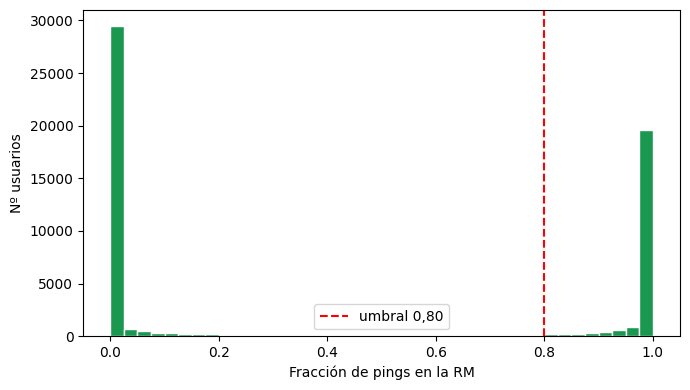

In [2]:
from evasion.config import (TELEFONIA, LAT_MIN_RM, LAT_MAX_RM,
                                 LON_MIN_RM, LON_MAX_RM, MIN_PINGS_DIA, RM_FRACCION_MIN)

# Cargar todos los archivos CDR en una sola tabla
archivos = sorted(glob.glob(str(Path(TELEFONIA) / '*.parquet')))
pedazos = []
for a in archivos:
    pedazos.append(pd.read_parquet(a, columns=['user_id', 'lat', 'lon', 'timestamp']))
raw = pd.concat(pedazos, ignore_index=True)
raw['fecha'] = pd.to_datetime(raw['timestamp']).dt.date

# Cuanto se movio = rango de latitud (max - min) pasado a km (1 grado de lat -> aprox 111 km).
por_dia = raw.groupby(['user_id', 'fecha'])
tabla = pd.DataFrame()
tabla['n_pings']   = por_dia.size()
tabla['km_movido'] = (por_dia['lat'].max() - por_dia['lat'].min()) * 111

print('Km recorridos (mediana) según nº de pings ese día:')
for desde, hasta, nombre in [(1, 2, '1-2'), (3, 4, '3-4'), (5, 5, '5'),
                             (6, 10, '6-10'), (11, 9999, '11 o más')]:
    sel = tabla[(tabla['n_pings'] >= desde) & (tabla['n_pings'] <= hasta)]
    print(f'  {nombre:>9} pings: {sel["km_movido"].median():.2f} km')

# Para cada usuario, qué fracción de sus pings cae dentro del rectángulo de la RM
raw['en_rm'] = raw['lat'].between(LAT_MIN_RM, LAT_MAX_RM) & raw['lon'].between(LON_MIN_RM, LON_MAX_RM)
frac_rm = raw.groupby('user_id')['en_rm'].mean()
print(f'\nUsuarios con 100% de pings en la RM: {(frac_rm == 1.0).sum():,}')
print(f'Usuarios con >= 80% en la RM:        {(frac_rm >= 0.8).sum():,}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(frac_rm, bins=40, color='#1a9850', edgecolor='white')
ax.axvline(RM_FRACCION_MIN, color='red', linestyle='--', label='umbral 0,80')
ax.set_xlabel('Fracción de pings en la RM'); ax.set_ylabel('Nº usuarios'); ax.legend()
plt.tight_layout(); plt.show()

del raw   

## 2. Emparejamiento CDR–Bip: de SWS a BallTree

El objetivo es vincular a cada persona con el bus que tomó. La propuesta original lo hacía
con SWS, una métrica que compara trayectorias continuas. Los datos Bip no son trayectorias
sino validaciones puntuales, así que en su lugar se busca co-ocurrencia: un ping del celular
cercano a una validación en espacio y tiempo.

Para encontrar esas co-ocurrencias entre millones de puntos se usa BallTree, una estructura
que busca vecinos cercanos de forma rápida. Se elige BallTree y no otra estructura, como KD-Tree, porque admite la
métrica haversine (distancia sobre la esfera terrestre); KD-Tree solo mide distancia
euclidiana, en linea recta.

Procedimiento: cada día se indexan los pings CDR en un BallTree y, para cada validación Bip,
se consultan los pings dentro de 100 m; luego se filtra por diferencia de tiempo (±3 min).

### 2.1 Las validaciones Bip son eventos puntuales (por eso no aplica SWS)

Si cada tarjeta valida una o dos veces al día, no hay trayectoria que comparar.

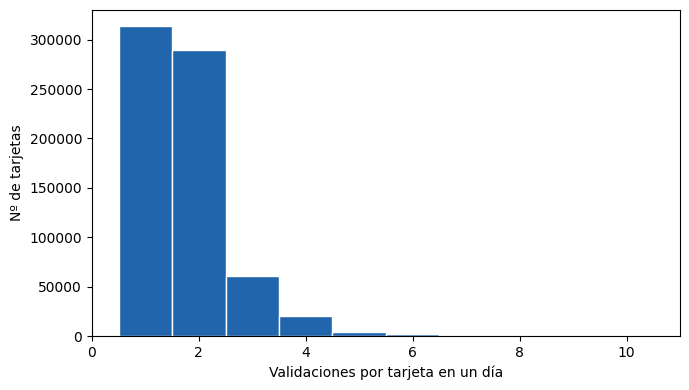

Mediana de validaciones por tarjeta al día: 2


In [3]:
arch_bip = sorted(glob.glob(str(DATA / 'viajes' / 'parquet' / '*.parquet')))[0]
tarjetas = pd.read_parquet(arch_bip, columns=['id_tarjeta'])

# Cuántas validaciones tiene cada tarjeta en ese día
val_por_tarjeta = tarjetas.groupby('id_tarjeta').size()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(val_por_tarjeta.clip(upper=10), bins=range(1, 12), align='left',
        color='#2166ac', edgecolor='white')   
ax.set_xlabel('Validaciones por tarjeta en un día'); ax.set_ylabel('Nº de tarjetas')
plt.tight_layout(); plt.show()
print('Mediana de validaciones por tarjeta al día:', int(val_por_tarjeta.median()))

### 2.2 BallTree frente a fuerza bruta

La alternativa (comparar cada validación con cada ping, una por una) es inviable a escala
real. Se mide el tiempo de ambos enfoques sobre una muestra de coordenadas.

In [4]:
from sklearn.neighbors import BallTree

bip_xy = pd.read_parquet(arch_bip, columns=['lat_subida', 'lon_subida']).dropna()
puntos = np.radians(bip_xy[['lat_subida', 'lon_subida']].values)   # BallTree usa radianes
referencia = puntos[:20000]      # puntos que se indexan
consultas  = puntos[20000:22000] # puntos que se buscan
radio = 100 / 6_371_000          # 100 m pasados a radianes (radio de la Tierra en m)

inicio = time.time()
arbol = BallTree(referencia, metric='haversine')
arbol.query_radius(consultas, r=radio)
t_balltree = time.time() - inicio

def distancia(a, B):   # distancia haversine de un punto a un array de puntos (en radianes)
    dlat = B[:, 0] - a[0]; dlon = B[:, 1] - a[1]
    h = np.sin(dlat/2)**2 + np.cos(a[0]) * np.cos(B[:, 0]) * np.sin(dlon/2)**2
    return 2 * np.arcsin(np.sqrt(h))

inicio = time.time()
for a in consultas:
    cercanos = np.where(distancia(a, referencia) <= radio)
t_bruta = time.time() - inicio

print(f'BallTree:     {t_balltree:.3f} s')
print(f'Fuerza bruta: {t_bruta:.3f} s  ({t_bruta / t_balltree:.0f}x más lenta)')

BallTree:     0.026 s
Fuerza bruta: 0.689 s  (27x más lenta)


### 2.3 Radio de 100 m y ventana de ±3 min

No hay un valor estándar en la literatura para estos umbrales; cada estudio que cruza CDR con transporte elige el suyo según sus datos. Lo que la literatura fija es el rango: el CDR ubica a nivel de antena, con precisión del orden de cientos de metros (González et al., 2008). Dentro de ese rango se elige 100 m, el extremo estricto, para priorizar precisión (no emparejar de más) sobre cobertura. La ventana de ±3 min sale de que el CDR registra la posición cada pocos minutos, así que es la tolerancia para encontrar el ping más cercano a cada validación.

La elección se respalda de tres formas: el rango lo fija la resolución del CDR; el requisito posterior de 3 días filtra los emparejamientos casuales; y un umbral más estricto perdería validadores reales por la imprecisión del CDR (con 50 m y ±1 min los validadores bajan de 1.852 a 292). Las distribuciones de distancia y tiempo de las coincidencias se muestran abajo.

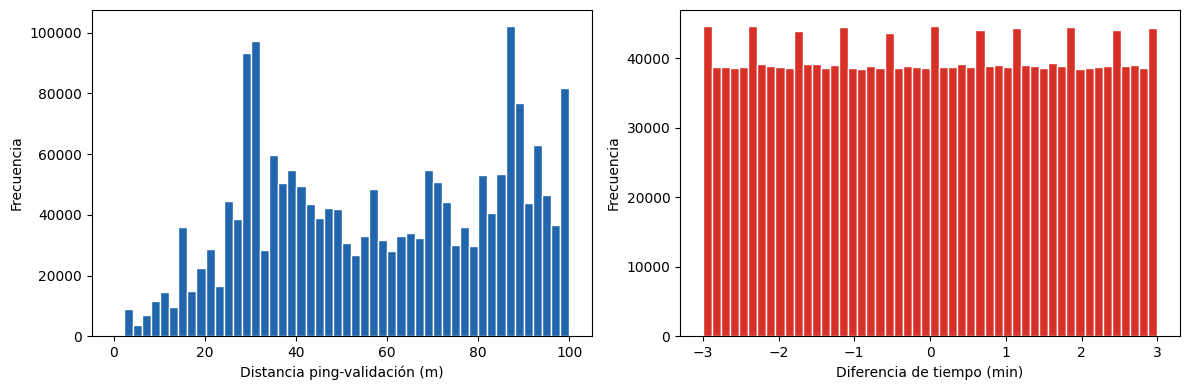

In [5]:
cand = pd.read_parquet(DATA / 'candidatos.parquet', columns=['distancia_m', 'delta_min'])
muestra = cand.sample(min(2_000_000, len(cand)), random_state=42)   # muestra para graficar más rápido

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.hist(muestra['distancia_m'], bins=50, color='#2166ac', edgecolor='white')
a1.set_xlabel('Distancia ping-validación (m)'); a1.set_ylabel('Frecuencia')
a2.hist(muestra['delta_min'], bins=50, color='#d73027', edgecolor='white')
a2.set_xlabel('Diferencia de tiempo (min)'); a2.set_ylabel('Frecuencia')
plt.tight_layout(); plt.show()

## 3. Validador consistente: 3 días con la misma tarjeta

Para cada par (usuario, tarjeta) se cuenta en cuántos días distintos coinciden. Con 3 o más
se etiqueta como validador consistente.

De Montjoye et al. (2013) mostraron que bastan 4 puntos espaciotemporales para identificar al
95% de las personas: este tipo de coincidencias es muy discriminante. El criterio de 3 días
se apoya en ese principio. La justificación directa es que coincidir con la misma tarjeta en
3 días distintos es muy improbable por azar, así que es evidencia fuerte de un vínculo real.
La tabla muestra el costo de subir el umbral: con 4 o más días quedan muy pocos usuarios.

In [6]:
ug = pd.read_parquet(DATA / 'usuarios_grupos.parquet')
for u in [2, 3, 4]:
    n = (ug['n_dias_max_tarjeta'] >= u).sum()
    print(f'>= {u} dias con la misma tarjeta: {n:,} usuarios')

>= 2 dias con la misma tarjeta: 6,405 usuarios
>= 3 dias con la misma tarjeta: 1,852 usuarios
>= 4 dias con la misma tarjeta: 509 usuarios


### 3.1 ¿Bastan 7 días de Bip? (suficiencia de los datos)

La etiqueta de validador depende de la ventana de 7 días de Bip. Para evaluar si esa ventana
basta, se mide cómo crece el número de validadores al usar los primeros 3, 4, ... 7 días. Si
la curva se aplana, 7 días capturan casi todos; si sigue subiendo, faltan datos.

La curva no se satura: cada día agrega validadores y el paso de 6 a 7 días es el que más
aporta. Esto indica que 7 días no alcanzan a capturar a todos los validadores, por lo que
parte de ellos quedan mal etiquetados como no-validadores. Es una limitación de la ventana
temporal de los datos Bip (no del umbral de 3 días) y justifica pedir una ventana más larga.

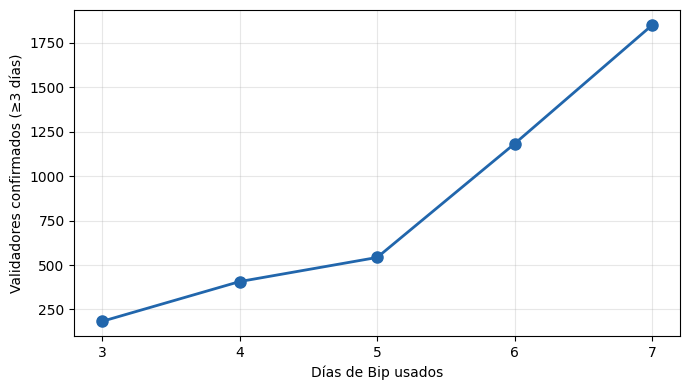

Validadores según nº de días: {3: 183, 4: 407, 5: 543, 6: 1184, 7: 1852}


In [7]:
import io, contextlib
from evasion.crossday import agregar_id_tarjeta

cand = pd.read_parquet(DATA / 'candidatos.parquet')
with contextlib.redirect_stdout(io.StringIO()):      # silencia los prints internos de la función
    cand = agregar_id_tarjeta(cand)
cand = cand[['usuario', 'id_tarjeta', 'fecha']].drop_duplicates()

dias = sorted(cand['fecha'].unique())
n_dias_usados = []
n_validadores = []
for k in range(3, len(dias) + 1):
    primeros_k = dias[:k]
    sub = cand[cand['fecha'].isin(primeros_k)]
    # días distintos que coincidió cada par (usuario, tarjeta)
    dias_por_par = sub.groupby(['usuario', 'id_tarjeta'])['fecha'].nunique()
    # para cada usuario, su mejor tarjeta (la de más días)
    mejor_por_usuario = dias_por_par.groupby('usuario').max()
    n_dias_usados.append(k)
    n_validadores.append(int((mejor_por_usuario >= 3).sum()))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_dias_usados, n_validadores, 'o-', color='#2166ac', linewidth=2, markersize=8)
ax.set_xlabel('Días de Bip usados'); ax.set_ylabel('Validadores confirmados (≥3 días)')
ax.set_xticks(n_dias_usados); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('Validadores según nº de días:', dict(zip(n_dias_usados, n_validadores)))

## 4. Clasificador

La lógica es de clasificación inversa: no existe una etiqueta de "evasor", así que se entrena
solo con los dos grupos de etiqueta clara: validador_consistente (usa transporte y valida) y
sin_uso_aparente (no usa transporte), con las 6 features de movilidad, y se aprende cómo se
mueve cada uno. Luego el modelo se aplica a todos. Un usuario que se mueve como validador
pero no valida de forma consistente queda marcado como no-validador probable.

Se entrena solo con los grupos extremos porque son los únicos sobre los que hay certeza; los
ambiguos son justamente lo que se quiere predecir, no datos para entrenar.

### Selección de las 6 features

Las features se eligieron para que cada una responda a una dimensión de la pregunta de investigación (socioespacial y temporal), sin repetirse:

- Espacial (red de transporte): frac_cerca_paradero, n_paraderos_distintos.
- Temporal (ritmo de commute): frac_manana, frac_tarde.
- Actividad (cuánto y con qué regularidad aparece el usuario): n_pings, n_dias_activos.

Se excluyeron a propósito las variables derivadas del propio cruce (nº de tarjetas, días de coincidencia) por circularidad: codifican la etiqueta y el modelo solo las repetiría. También se descartaron las features de velocidad (vel_mediana, vel_p90) porque no mapean a la pregunta (no son espaciales, temporales ni socioeconómicas) y su importancia era despreciable (<0,04); quitarlas no cambia el F1. La importancia de variables (figuras/importancia_features.png) confirma que las de paraderos son las que más aportan.

### 4.1 Comparación de modelos

Se comparan tres modelos (regresión logística, random forest, XGBoost) contra dos baselines sin cerebro (Dummy), con validación cruzada de 5 folds. Los baselines dan el piso: si un modelo no les gana, no está aprendiendo nada. Se reporta F1, estándar cuando las clases están desbalanceadas; en este caso las cuatro métricas dan parecido porque los dos grupos se separan con facilidad.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

features = pd.read_parquet(DATA / 'features.parquet')
FEATURES = ['n_pings', 'n_dias_activos', 'frac_cerca_paradero', 'n_paraderos_distintos',
            'frac_manana', 'frac_tarde']

# Solo los dos grupos con etiqueta clara
ent = features[features['grupo'].isin(['validador_consistente', 'sin_uso_aparente'])].copy()
X = ent[FEATURES].values
y = (ent['grupo'] == 'validador_consistente').astype(int).values   # 1 = validador, 0 = sin uso
peso = (y == 0).sum() / (y == 1).sum()   # para que XGBoost compense el desbalance

# Si un modelo no les gana, no está aprendiendo nada
modelos = {
    'Dummy (mayoritaria)':   DummyClassifier(strategy='most_frequent'),
    'Dummy (estratificado)': DummyClassifier(strategy='stratified', random_state=42),
    'Regresión Logística': make_pipeline(
        SimpleImputer(strategy='median'), StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight='balanced')),
    'Random Forest': make_pipeline(
        SimpleImputer(strategy='median'),
        RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    'XGBoost': make_pipeline(
        SimpleImputer(strategy='median'),
        XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                      scale_pos_weight=peso, random_state=42, eval_metric='logloss')),
}

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
filas = []
for nombre, modelo in modelos.items():
    r = cross_validate(modelo, X, y, cv=kfold, scoring=['accuracy', 'precision', 'recall', 'f1'])
    filas.append({'modelo': nombre,
                  'accuracy':  r['test_accuracy'].mean(),
                  'precision': r['test_precision'].mean(),
                  'recall':    r['test_recall'].mean(),
                  'f1':        r['test_f1'].mean()})
pd.DataFrame(filas).set_index('modelo').round(3)

,accuracy,precision,recall,f1
modelo,,,,
Dummy (mayoritaria),0.768,0.000,0.000,0.000
Dummy (estratificado),0.641,0.230,0.234,0.232
Regresión Logística,0.952,0.862,0.945,0.902
Random Forest,0.966,0.949,0.902,0.925
XGBoost,0.961,0.891,0.947,0.918


Los baselines confirman que el modelo aprende algo real: les gana por lejos (las Dummy quedan muy abajo). Y la regresión logística queda casi igual que el random forest, lo que muestra que el problema es fácil de separar y que un modelo más complejo aporta poco. Se elige Random Forest porque da el mejor F1 y entrega importancia de variables.

### 4.2 Hiperparámetros

Se prueban varias combinaciones de hiperparámetros de Random Forest y XGBoost con GridSearch (validación cruzada) y se adopta la de mejor F1, en vez de usar los valores por defecto.

In [9]:
from sklearn.model_selection import GridSearchCV

rf = make_pipeline(SimpleImputer(strategy='median'),
                   RandomForestClassifier(class_weight='balanced', random_state=42))
rejilla_rf = {'randomforestclassifier__n_estimators': [100, 300],
              'randomforestclassifier__max_depth': [None, 6, 12],
              'randomforestclassifier__min_samples_leaf': [1, 5]}
busqueda_rf = GridSearchCV(rf, rejilla_rf, scoring='f1', cv=kfold, n_jobs=-1).fit(X, y)

xgb = make_pipeline(SimpleImputer(strategy='median'),
                    XGBClassifier(scale_pos_weight=peso, random_state=42, eval_metric='logloss'))
rejilla_xgb = {'xgbclassifier__n_estimators': [100, 300],
               'xgbclassifier__max_depth': [3, 5],
               'xgbclassifier__learning_rate': [0.05, 0.1]}
busqueda_xgb = GridSearchCV(xgb, rejilla_xgb, scoring='f1', cv=kfold, n_jobs=-1).fit(X, y)

print(f'Random Forest mejor F1: {busqueda_rf.best_score_:.3f}  {busqueda_rf.best_params_}')
print(f'XGBoost mejor F1:       {busqueda_xgb.best_score_:.3f}  {busqueda_xgb.best_params_}')

Random Forest mejor F1: 0.925  {'randomforestclassifier__max_depth': 12, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 100}
XGBoost mejor F1:       0.919  {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 100}


Se adopta Random Forest con max_depth=12 y 300 árboles (F1 = 0,926), ya incorporado en
`evasion/clasificador.py`.

### 4.3 Umbral de decisión

El modelo no entrega un sí/no, sino una probabilidad de 0 a 1 de que un usuario tenga patrón
de validador. El umbral es el corte que la convierte en sí/no: con 0,45, a quien tenga 0,45 o
más se le marca como validador. No es la probabilidad de evadir, sino la vara de cuán seguro
debe estar el modelo. Se prueba cada corte y se elige el de mejor F1.

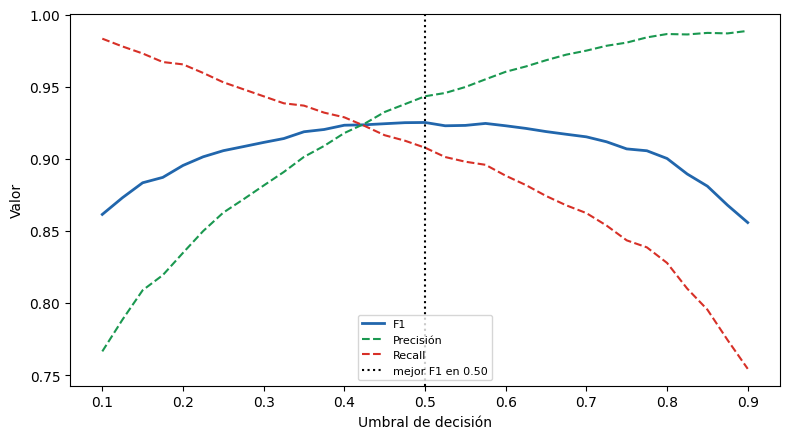

Mejor F1 = 0.925 en umbral 0.50


In [10]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score, precision_score, recall_score

# Probabilidad de cada usuario (estimada con validación cruzada, sin que el modelo lo haya visto)
proba = cross_val_predict(busqueda_rf.best_estimator_, X, y, cv=kfold, method='predict_proba')[:, 1]

# Probar cada umbral y guardar las tres métricas
umbrales = np.linspace(0.1, 0.9, 33)
f1s, precisiones, recalls = [], [], []
for t in umbrales:
    prediccion = (proba >= t).astype(int)   # marcar como validador si la probabilidad supera t
    f1s.append(f1_score(y, prediccion))
    precisiones.append(precision_score(y, prediccion))
    recalls.append(recall_score(y, prediccion))

mejor_umbral = umbrales[int(np.argmax(f1s))]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(umbrales, f1s, label='F1', color='#2166ac', linewidth=2)
ax.plot(umbrales, precisiones, '--', label='Precisión', color='#1a9850')
ax.plot(umbrales, recalls, '--', label='Recall', color='#d73027')
ax.axvline(mejor_umbral, color='black', linestyle=':', label=f'mejor F1 en {mejor_umbral:.2f}')
ax.set_xlabel('Umbral de decisión'); ax.set_ylabel('Valor'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f'Mejor F1 = {max(f1s):.3f} en umbral {mejor_umbral:.2f}')

El F1 se maximiza en 0,45; ese umbral se adopta en `evasion/clasificador.py`.

## 5. Estimación del hogar: pings nocturnos (22-7h)

Para asignar a cada usuario una comuna se estima su hogar con los pings entre las 22 y las
7 h, tomando la mediana de su ubicación. Usar el horario nocturno como ancla del lugar de
residencia es una técnica estándar en estudios de movilidad con datos móviles (Ahas et al.,
2010): a esas horas la persona está mayoritariamente en su casa.

El hogar se usa solo para asignar una comuna, no una ubicación precisa, así que la resolución
del CDR alcanza. Se comparó con usar la ubicación más frecuente de todo el día (ver
01_exploracion) y la versión nocturna estima mejor la residencia.

In [11]:
hogar = pd.read_parquet(DATA / 'hogar.parquet')
print(f'Usuarios con hogar estimado: {len(hogar):,}')
print(f'Con comuna asignada:         {hogar["comuna_gadm"].notna().sum():,}')

Usuarios con hogar estimado: 18,779
Con comuna asignada:         17,236


## 6. Tasa de no-validación por comuna y umbral de 100

Por comuna se calcula: de las personas que viven ahí y se mueven como usuarios de transporte
(patron_similar = True), qué fracción no son validadores confirmados. Esta definición es
consecuencia directa de la lógica inversa: el no-validador se mueve como validador pero sin
validación consistente.

Comunas con pocos usuarios dan fracciones poco confiables, así que solo se incluyen las que
tienen al menos 100. La tabla compara umbrales. Las comunas rurales periféricas, donde el
transporte no usa Bip, quedan fuera por este filtro, coherente con el alcance del estudio.

La tabla incluye además moran_I y p_moran, que miden el agrupamiento espacial de la tasa: se explican en la sección 7.

In [12]:
from evasion.socioeconomico import cargar_pobreza, calcular_tasa_por_comuna
from evasion.espacial import cargar_geometria_con_tasas, construir_pesos, moran_global
from scipy import stats

feat_cls = pd.read_parquet(DATA / 'features_clasificados.parquet')
hogar = pd.read_parquet(DATA / 'hogar.parquet')
pobreza = cargar_pobreza()

filas = []
for umbral in [50, 100, 150, 200]:
    tasa = calcular_tasa_por_comuna(feat_cls, hogar, min_usuarios=umbral)
    df = tasa.merge(pobreza, on='clave_match', how='inner')
    r, p = stats.spearmanr(df['tasa_no_validacion'], df['tasa_pobreza'])
    geo = cargar_geometria_con_tasas(df)
    w = construir_pesos(geo, k=5)
    moran = moran_global(geo, w)
    filas.append({'umbral': umbral, 'comunas': len(df),
                  'spearman_r': round(r, 3), 'p_corr': round(p, 3),
                  'moran_I': round(moran.I, 3), 'p_moran': round(moran.p_sim, 3)})
pd.DataFrame(filas).set_index('umbral')

  Comunas RM en datos de pobreza: 52
  Comunas con >= 50 usuarios: 35 de 51
  Cargando comunas de GADM...


  Comunas RM cargadas: 52
  Comunas con geometría y tasa: 35
  Vecindad KNN con k=5 (cada comuna tiene 5 vecinos)

  Moran's I global = 0.235
  p-valor          = 0.0050  (autocorrelación significativa)
  Comunas con >= 100 usuarios: 30 de 51
  Cargando comunas de GADM...


  Comunas RM cargadas: 52
  Comunas con geometría y tasa: 30
  Vecindad KNN con k=5 (cada comuna tiene 5 vecinos)

  Moran's I global = 0.321
  p-valor          = 0.0010  (autocorrelación significativa)
  Comunas con >= 150 usuarios: 20 de 51
  Cargando comunas de GADM...


  Comunas RM cargadas: 52
  Comunas con geometría y tasa: 20
  Vecindad KNN con k=5 (cada comuna tiene 5 vecinos)

  Moran's I global = 0.078
  p-valor          = 0.1000  (NO significativo)
  Comunas con >= 200 usuarios: 12 de 51
  Cargando comunas de GADM...


  Comunas RM cargadas: 52
  Comunas con geometría y tasa: 12
  Vecindad KNN con k=5 (cada comuna tiene 5 vecinos)

  Moran's I global = -0.071
  p-valor          = 0.3800  (NO significativo)


,comunas,spearman_r,p_corr,moran_I,p_moran
umbral,,,,,
50,35,0.218,0.209,0.235,0.005
100,30,0.328,0.077,0.321,0.001
150,20,0.241,0.307,0.078,0.100
200,12,0.699,0.011,-0.071,0.380


### 6.1 Correlación de Spearman 

La correlación con la pobreza (la tabla de arriba, calculada con Spearman) es el resultado socioeconómico central: indica si las comunas con más pobreza tienen más no-validación. El coeficiente va de -1 a 1: el signo dice la dirección (positivo = a más pobreza, más no-validación) y el tamaño dice la fuerza (0 a 0,3 débil; 0,3 a 0,5 moderada; sobre 0,5 fuerte). El valor obtenido (~0,35) es positivo y moderado.

Spearman se basa en el orden (ranking) de las comunas, así que no supone una relación de línea recta y aguanta comunas atípicas; la correlación de Pearson sí supone línea recta. Abajo se calculan las dos solo para mostrar que dan un valor parecido, es decir, que la conclusión no depende del método elegido.

In [13]:
df_corr = calcular_tasa_por_comuna(feat_cls, hogar, min_usuarios=100).merge(
    pobreza, on='clave_match', how='inner')
x = df_corr['tasa_no_validacion'].astype(float)
y_pob = df_corr['tasa_pobreza'].astype(float)
print('Pearson  (supone línea recta):', round(stats.pearsonr(x, y_pob)[0], 3))
print('Spearman (usa el ranking)    :', round(stats.spearmanr(x, y_pob)[0], 3))

  Comunas con >= 100 usuarios: 30 de 51
Pearson  (supone línea recta): 0.398
Spearman (usa el ranking)    : 0.328


## 7. Vecindad espacial: KNN

El análisis espacial usa dos medidas. Moran's I es global: un solo número que dice si, en
todo Santiago, las comunas con tasas parecidas están agrupadas (no dice dónde). LISA es
local: lo descompone por comuna e identifica cuáles forman foco caliente o zona fría. Moran
responde si hay patrón; LISA responde dónde.

Ambas necesitan definir qué comunas son vecinas. Se usa KNN con k = 5 y no contigüidad (compartir frontera)
porque, al filtrar comunas, quedan huecos en el mapa y la contigüidad dejaría comunas sin
vecinas, rompiendo el cálculo. En la salida, Moran's I (de ~0 a ~1) dice si las comunas con tasas parecidas están agrupadas, y el p-valor dice si ese agrupamiento es real o podría ser azar (p<0,05 = real). No se busca un k óptimo: k=5 es un valor estándar y lo importante es que el resultado se mantiene para k=4, 5, 6 y 8.

In [14]:
from libpysal.weights import KNN
from esda.moran import Moran

ev = pd.read_parquet(DATA / 'evasion_por_comuna.parquet')
geo = cargar_geometria_con_tasas(ev)
valores = geo['tasa_no_validacion'].values

for k in [4, 5, 6, 8]:
    w = KNN.from_dataframe(geo, k=k)
    w.transform = 'r'                      # normalizar pesos por fila
    moran = Moran(valores, w, permutations=999)
    print(f'k={k}: Moran I={moran.I:.3f}  p={moran.p_sim:.3f}')

  Cargando comunas de GADM...


  Comunas RM cargadas: 52
  Comunas con geometría y tasa: 30
k=4: Moran I=0.377  p=0.002
k=5: Moran I=0.321  p=0.004
k=6: Moran I=0.308  p=0.002
k=8: Moran I=0.236  p=0.003


## Resumen

| # | Decisión | Valor | Cómo se validó |
|---|---|---|---|
| 1 | Mín. pings/día | 5 | km recorridos casi nulos con menos pings |
| 1 | Fracción en RM | ≥0,80 | bimodal; exigir 100% pierde 22% de residentes |
| 2 | Métrica de cruce | BallTree | Bip discreto (no SWS); haversine; más rápido |
| 2 | Radio / ventana | 100 m / ±3 min | precisión CDR; distribución de coincidencias |
| 3 | Validador consistente | ≥3 días | De Montjoye 2013; tabla de costo; saturación |
| 4 | Lógica del clasificador | inversa (entrena extremos) | conceptual + estructura de grupos |
| 4 | Clasificador | RF (max_depth=12, 300) | comparación + GridSearch |
| 4 | Umbral de decisión | 0,45 | barrido de F1 |
| 5 | Estimación de hogar | pings 22-7h | Ahas et al. 2010 (técnica estándar) |
| 6 | Definición de la tasa | lógica inversa | consecuencia del clasificador |
| 6 | Umbral de comunas | ≥100 | sensibilidad |
| 6 | Correlación | Spearman | no asume linealidad; ≈ Pearson |
| 7 | Vecindad espacial | KNN (k=5) | estabilidad en k |

## Referencias

- Ahas, R., Silm, S., Järv, O., Saluveer, E. y Tiru, M. (2010). Using mobile positioning data
  to model locations meaningful to users of mobile phones. *Journal of Urban Technology*,
  17(1), 3-27.
- De Montjoye, Y.-A., Hidalgo, C. A., Verleysen, M. y Blondel, V. D. (2013). Unique in the
  crowd: The privacy bounds of human mobility. *Scientific Reports*, 3, 1376.
- González, M. C., Hidalgo, C. A. y Barabási, A.-L. (2008). Understanding individual human
  mobility patterns. *Nature*, 453, 779-782.